# Section 3 Extension: Noise Robustness

This notebook tests how Gaussian full-information feedback noise affects Section 3. Each round observes the full matrix sample `A_t = clip(A + sigma * Gaussian, 0, 1)`. The algorithms are Nash, Hedge, and the official Our-Algo variant.

In [1]:
from pathlib import Path
from IPython.display import Image, display

from section3_noise_robustness import run_and_plot, print_summary


## Run Experiment

Use `quick` for a fast check. Use `medium` or `paper-lite` for report-quality runs.

In [2]:
preset = "medium"  # options: "quick", "medium", "paper-lite"
seed = 7

bundle, regret_path, payoff_path = run_and_plot(preset, seed=seed)
metadata = bundle["metadata"]
results = bundle["results"]
metadata



-- n=10 -------------------------------------------------------
  sigma=0.00  Nash: R=    0.01, P=0.0492  Hedge: R=    3.81, P=0.0490  Our-Algo: R=    3.92, P=0.0491  
  sigma=0.10  Nash: R=    5.60, P=0.0490  Hedge: R=    4.20, P=0.0490  Our-Algo: R=    4.20, P=0.0491  
  sigma=0.20  Nash: R=   10.45, P=0.0488  Hedge: R=    5.89, P=0.0490  Our-Algo: R=    4.63, P=0.0491  
  sigma=0.30  Nash: R=   35.56, P=0.0480  Hedge: R=    8.96, P=0.0489  Our-Algo: R=    5.96, P=0.0491  

-- n=20 -------------------------------------------------------
  sigma=0.00  Nash: R=    0.00, P=0.0246  Hedge: R=    2.48, P=0.0245  Our-Algo: R=    4.17, P=0.0246  
  sigma=0.10  Nash: R=    3.29, P=0.0245  Hedge: R=    2.99, P=0.0245  Our-Algo: R=    4.22, P=0.0246  
  sigma=0.20  Nash: R=    7.07, P=0.0244  Hedge: R=    4.91, P=0.0245  Our-Algo: R=    4.36, P=0.0246  
  sigma=0.30  Nash: R=   21.26, P=0.0239  Hedge: R=    8.57, P=0.0243  Our-Algo: R=    4.91, P=0.0245  

-- n=50 -----------------------------

{'preset': 'medium',
 'sigma_values': [0.0, 0.1, 0.2, 0.3],
 'n_runs': 8,
 'horizon': 30000}

## Generated Plots

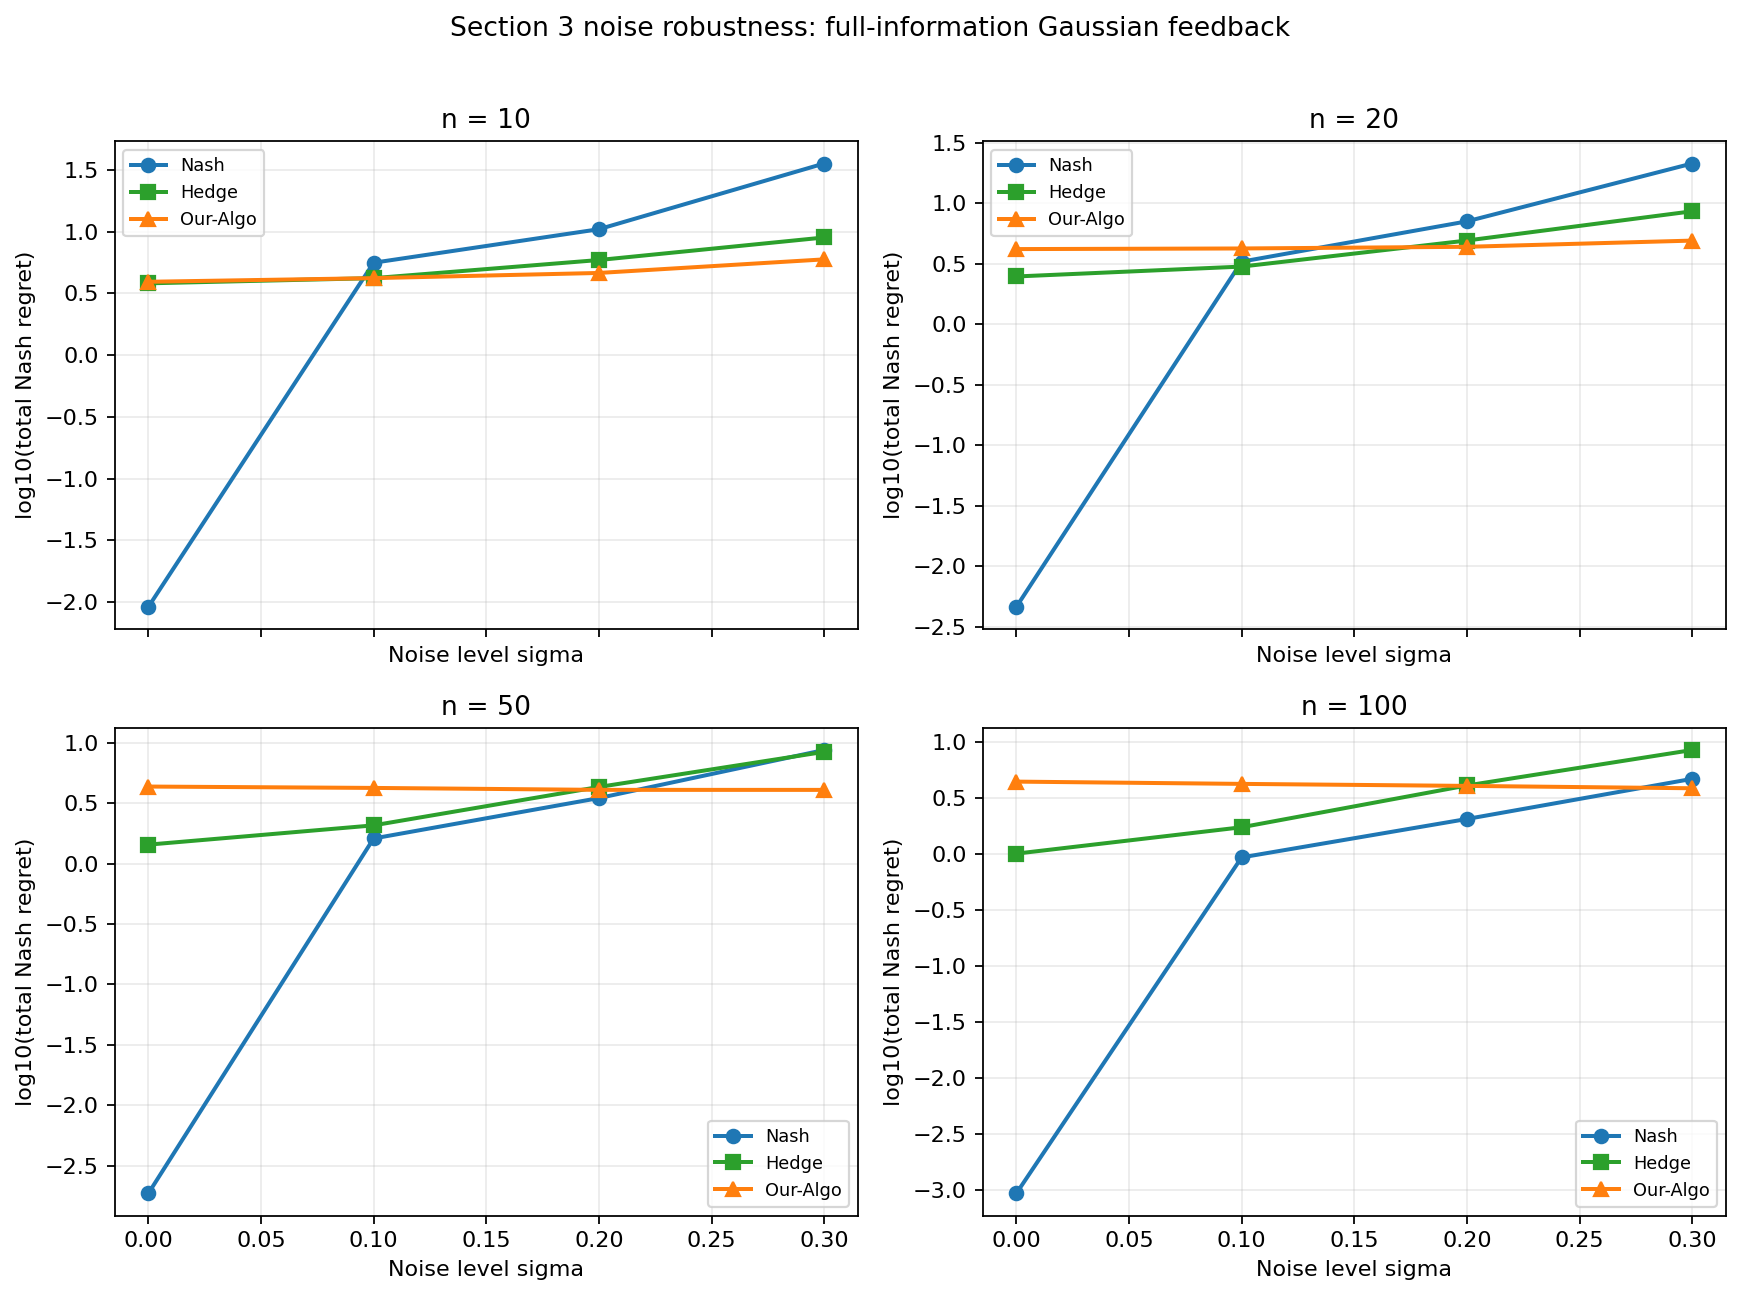

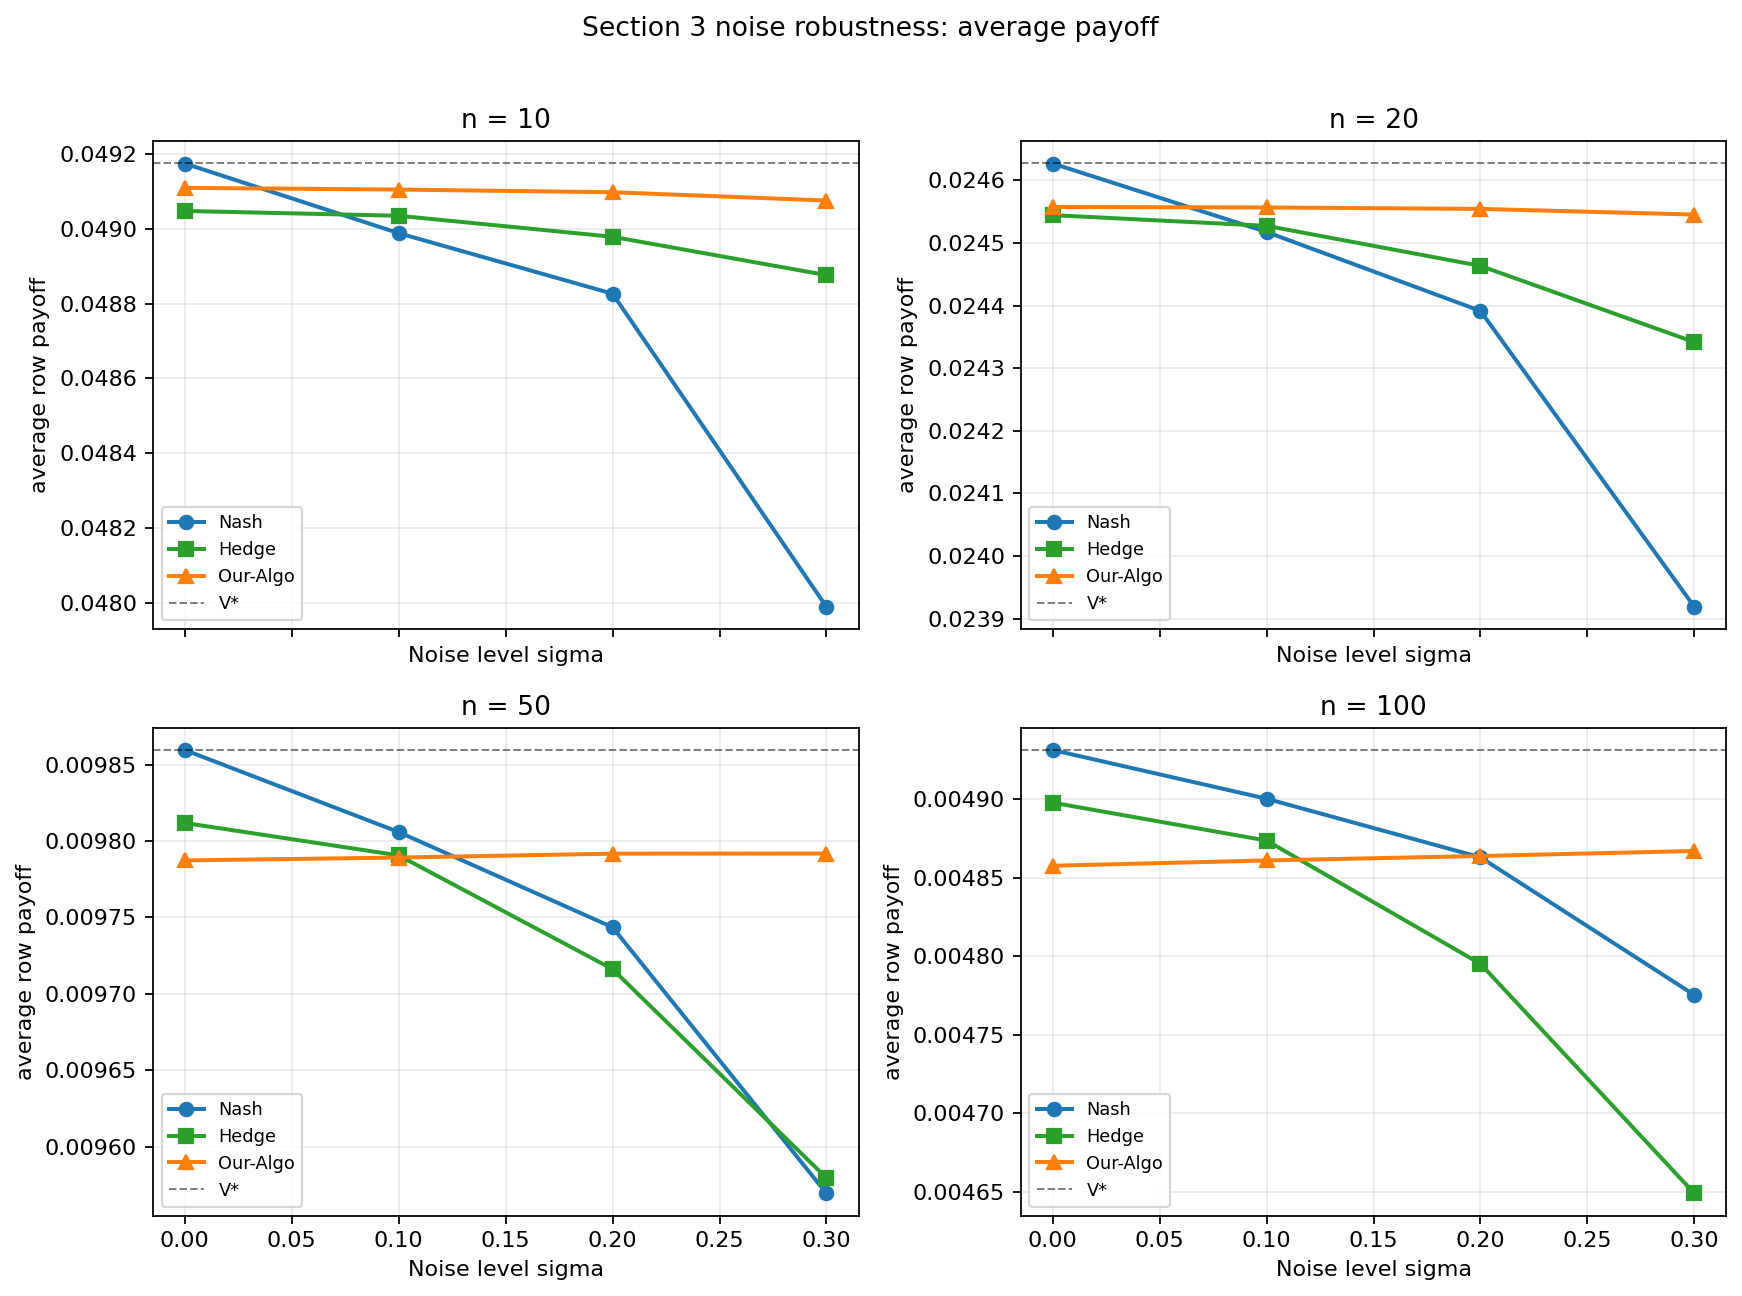

In [3]:
display(Image(filename=str(regret_path)))
display(Image(filename=str(payoff_path)))


## Interpretation

Section 3 uses full-information feedback, so the learner sees much more data each round than in the bandit setting. The expected behavior is a gradual degradation as `sigma` increases, rather than a sudden collapse.